<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW5_boosting_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашняя работа: прогнозирование заработной платы и кластеризация типов движений**

### **Постановка задачи:**

В этой работе две части:

*   В первой части вам предстоит построить алгоритм на основе бустинга для прогнозирования зарплаты
*   Во второй части вам предстоит кластеризовать типы движений по имеющимся данным с акселерометров и гироскопов

### **Оценивание:**

- Как всегда оцениваются как код, так и ответы на вопросы. Если нет одного и/или другого, то часть баллов за соответствующее задание без колебаний снимается.
- Брать код из открытых источников позволительно. Следование культуре цитирования **обязательно.**

### **Баллы:**

Суммарно за задание можно получить 10 основных и 1 бонусный балл.

Оценка за ДЗ = min{ваш балл, 10}

**Интересной вам работы!**


# **Часть 1. Прогнозирование заработной платы при помощи бустинга**

**Количество баллов:** 7

## **Постановка задачи:**

Данные выгружены и лежат в файле `ds_salary.csv`. Вам доступны описания признаков и значения целевой переменной.

**Ваша задача:** построение модели бустинга и оценка данной модели.

## **Описание даных**

- work_year: год, в который взяты данные;
- experience_level: уровень опыта, кодируемый как SE, MI EN или EX
- employment_type: тип занятости (FT, PT, CT, FL)
- job_title: название рабочей позиции в компании;
- salary: зараплата на позиции;
- salary_currency: валюта в которой начисляют зарплату;
- employee_residence: страна или регион проживания сотрудника
- remote_ratio: процент удаленки, предлагаемый в компании (0, 50, 100)
- company_location: местоположение компании
- company_size: размер компании, оцененный как S, M, L
- salary_in_usd: целевая переменная


Как всегда, загрузим набор данных.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://github.com/hse-ds/iad-intro-ds/raw/refs/heads/master/2023/homeworks/hw-08-boosting/ds_salaries.csv")

## **Задание 1 (0.3 балла)**

Вам даны описания переменных. Проверьте, что категориальные признаки, категории которых перечислены, не имеют ошибочных значений. Для этого:

- Напишите цикл, пробегающий по выбранным признакам и оценивающий, что в них нет лишних значений;

In [3]:
allowed = {
    "experience_level": {"SE", "MI", "EN", "EX"},
    "employment_type": {"FT", "PT", "CT", "FL"},
    "remote_ratio": {0, 50, 100},
    "company_size": {"S", "M", "L"},
}

for col, ok in allowed.items():
    bad = set(df[col].dropna().unique()) - ok
    if bad:
        print(col, sorted(bad))

## **Задание 2 (0.3 балла)**

Проведите базовые шаги оценки качества данных.
- Есть есть проблемы, устраните их;
- Если нет проблем, кратко опишите это.

In [4]:
df = df.copy()

print("shape:", df.shape)

print("\nna:")
print(df.isna().sum())

df = df.drop_duplicates()

num_cols = df.select_dtypes(include="number").columns

for c in num_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1

    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    df = df[(df[c] >= low) & (df[c] <= high)]

print("\nfinal shape:", df.shape)

shape: (3755, 11)

na:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

final shape: (2416, 11)


## **Задание 3 (0.3 балла)**

Вернитесь к описанию признаков.
- Проверьте, все ли признаки соответствуют постановке задачи? Если есть лишние признаки, удалите их и обоснуйте удаление, если нет, сделайте вывод о релевантности (достаточно в одну-две строки)
- Зафиксируйте, в каких признаках много категорий.

In [5]:
target = "salary_in_usd"

cols = df.columns.tolist()

drop_cols = ["salary"]

df = df.drop(columns=drop_cols)

print("используемые признаки:", df.columns.tolist())

cat_cols = df.select_dtypes(include="object").columns

for c in cat_cols:
    print(c, df[c].nunique())

используемые признаки: ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']
experience_level 4
employment_type 4
job_title 87
salary_currency 12
employee_residence 74
company_location 67
company_size 3


**Ваши выводы здесь**

>  salary_currency лишнее тк целевая переменная присвоена к usdt



## **Задание 4 (0.2 балла)**

Разделите выборку на train, test (80%, 20%).

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["salary_in_usd"])
y = df["salary_in_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(1932, 9) (484, 9)


## **Задание 5 (0.3 балла)**

Будем проверять два сценария. Первый — построение модели только на непрерывных признаках, а второй — построение с категориальными. В этом задании подготовьте всё, чтобы проверить валидность обоих сценариев. А именно:

- Выделите данные для тренировки и теста для непрерывных признаков
- Выделите данные для тренировки и теста для непрерывных + категориальных признаков, пока ничего не кодируйте.

In [7]:
num_cols = X_train.select_dtypes(include="number").columns.tolist()

cat_cols = X_train.select_dtypes(include="object").columns.tolist()


X_train_num = X_train[num_cols]
X_test_num  = X_test[num_cols]


X_train_full = X_train[num_cols + cat_cols]
X_test_full  = X_test[num_cols + cat_cols]


print("numeric:", X_train_num.shape, X_test_num.shape)

print("full:", X_train_full.shape, X_test_full.shape)

numeric: (1932, 2) (484, 2)
full: (1932, 9) (484, 9)


## **Задание 6 (0.2 балла)**

- Обучите модель линейной регресии на числовых признаках и оцените её качество через mape и rmse;
- Сделайте вывод о качестве построенной модели;

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

model = LinearRegression()

model.fit(X_train_num, y_train)

pred = model.predict(X_test_num)

mape = mean_absolute_percentage_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAPE:", mape)
print("RMSE:", rmse)

MAPE: 0.578317001291346
RMSE: 60990.59556881189


## **Задание 8 (0.2 балла)**

- Обучите модель бустинга (любую из трех библиотек catboost, xgboost, lightgbm) с гиперпараметрами по умолчанию на непрерывных признаках и оцените её качество через mape и rmse;
- Сделайте вывод о качестве построенной модели;

In [10]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.9 MB/s eta 0:00:00


In [11]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

model = CatBoostRegressor(
    verbose=0,
    random_state=42
)

model.fit(X_train_num, y_train)

pred = model.predict(X_test_num)

mape = mean_absolute_percentage_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAPE:", mape)
print("RMSE:", rmse)

MAPE: 0.5731813316807733
RMSE: 60310.54812950273


## **Задание 9 (0.8 балла)**

Теперь подключим категориальные признаки. Но попробуем разные стратегии предобработки.

**1:**
- Предобработайте категориальные признаки при помощи OHE
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

**2:**
- Предобработайте категориальные признаки при помощи LabelEncoding
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

**3:**
- Предобработайте категориальные признаки при помощи MeanTargetEnc
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

Сделайте выводы по построениям 1-3. Выберите лучшую модель и дальше поработайте с ней.

In [12]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

ohe = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

lr_ohe = Pipeline([
    ("prep", ohe),
    ("model", LinearRegression())
])

xgb_ohe = Pipeline([
    ("prep", ohe),
    ("model", XGBRegressor(random_state=42))
])

lr_ohe.fit(X_train_full, y_train)
xgb_ohe.fit(X_train_full, y_train)

pred_lr = lr_ohe.predict(X_test_full)
pred_xgb = xgb_ohe.predict(X_test_full)

print("OHE LR  MAPE:", mean_absolute_percentage_error(y_test, pred_lr))
print("OHE LR  RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))

print("OHE XGB MAPE:", mean_absolute_percentage_error(y_test, pred_xgb))
print("OHE XGB RMSE:", np.sqrt(mean_squared_error(y_test, pred_xgb)))

OHE LR  MAPE: 0.3508520413386691
OHE LR  RMSE: 46524.01335264567
OHE XGB MAPE: 0.32168594002723694
OHE XGB RMSE: 46569.139996353806


In [13]:
from sklearn.preprocessing import OrdinalEncoder

ord_enc = ColumnTransformer(
    [
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

lr_le = Pipeline([
    ("prep", ord_enc),
    ("model", LinearRegression())
])

xgb_le = Pipeline([
    ("prep", ord_enc),
    ("model", XGBRegressor(random_state=42))
])

lr_le.fit(X_train_full, y_train)
xgb_le.fit(X_train_full, y_train)

pred_lr = lr_le.predict(X_test_full)
pred_xgb = xgb_le.predict(X_test_full)

print("LE LR  MAPE:", mean_absolute_percentage_error(y_test, pred_lr))
print("LE LR  RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))

print("LE XGB MAPE:", mean_absolute_percentage_error(y_test, pred_xgb))
print("LE XGB RMSE:", np.sqrt(mean_squared_error(y_test, pred_xgb)))

LE LR  MAPE: 0.40851475583809266
LE LR  RMSE: 51696.952053449335
LE XGB MAPE: 0.34840115904808044
LE XGB RMSE: 48319.50993128966


In [15]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.3 MB/s eta 0:00:00


In [16]:
import category_encoders as ce

target_enc = ColumnTransformer(
    [
        ("cat", ce.TargetEncoder(cols=cat_cols), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

lr_te = Pipeline([
    ("prep", target_enc),
    ("model", LinearRegression())
])

xgb_te = Pipeline([
    ("prep", target_enc),
    ("model", XGBRegressor(random_state=42))
])

lr_te.fit(X_train_full, y_train)
xgb_te.fit(X_train_full, y_train)

pred_lr = lr_te.predict(X_test_full)
pred_xgb = xgb_te.predict(X_test_full)

print("TE LR  MAPE:", mean_absolute_percentage_error(y_test, pred_lr))
print("TE LR  RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))

print("TE XGB MAPE:", mean_absolute_percentage_error(y_test, pred_xgb))
print("TE XGB RMSE:", np.sqrt(mean_squared_error(y_test, pred_xgb)))

TE LR  MAPE: 0.388184415609085
TE LR  RMSE: 47438.050918937544
TE XGB MAPE: 0.35180535912513733
TE XGB RMSE: 49946.35714444047


## **Задание 10 (0.5 балла)**

Покажите, где ошибается ваша модель. Выведите топ 20 примеров с наибольшей ошибкой. Проанализируйте их. Какие выводы можно сделать? Что стоит изменить в данных чтобы улучшить качество модели?

In [17]:
best_model = xgb_ohe

pred = best_model.predict(X_test_full)

errors = np.abs(y_test - pred)

analysis = X_test_full.copy()
analysis["real_salary"] = y_test.values
analysis["pred_salary"] = pred
analysis["abs_error"] = errors

top20 = analysis.sort_values("abs_error", ascending=False).head(20)

top20

,work_year,remote_ratio,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size,real_salary,pred_salary,abs_error
3560,2021,100,EN,FT,Machine Learning Scientist,USD,US,US,L,225000,81789.515625,143210.484375
2708,2022,100,SE,FT,ETL Developer,USD,US,US,M,250000,108488.937500,141511.062500
836,2023,100,EN,FT,AI Developer,EUR,DE,DE,L,214618,78696.179688,135921.820312
687,2023,0,SE,FT,Data Science Manager,USD,US,US,M,299500,164996.843750,134503.156250
113,2023,50,EN,FT,Research Scientist,USD,US,US,L,220000,86269.710938,133730.289062
1847,2022,0,MI,FT,Data Engineer,USD,US,US,M,260000,127237.328125,132762.671875
3387,2022,100,SE,FT,Data Engineer,USD,US,US,M,25000,156066.109375,131066.109375
254,2023,0,SE,FT,Research Engineer,USD,US,US,M,293000,163898.890625,129101.109375
2500,2022,100,MI,FT,Research Engineer,USD,US,US,M,240000,115283.617188,124716.382812
779,2023,100,SE,FT,ML Engineer,USD,CA,CA,M,260000,137696.421875,122303.578125


**Ваш ответ здесь**.
высокооплачиваемые сеньоры все ломают) + редкие комбинации признаков

## **Задание 11 (0.5 балла)**

Придумайте признаки для улучшения качества модели на основе предыдущего пункта. Как вам кажется какими признаками можно улучшить качетсво модели? Реализуйте признаки и проверьте улучшилось ли качество модели.

**Примечание:**
Полный балл за задание ставится даже при отсутствии улучшения качества модели, важно попробовать проверить свои гипотезы и сделать выводы.

In [18]:
def add_features(df):
    df = df.copy()

    df["is_senior"] = df["experience_level"].isin(["SE", "EX"]).astype(int)

    df["role_group"] = (
        df["job_title"]
        .str.lower()
        .apply(lambda x:
               "manager" if "manager" in x else
               "engineer" if "engineer" in x else
               "scientist" if "scientist" in x else
               "architect" if "architect" in x else
               "analyst" if "analyst" in x else
               "other")
    )

    europe = ["DE", "FR", "ES", "IT", "NL", "PL"]
    df["is_europe"] = df["company_location"].isin(europe).astype(int)

    df["is_us"] = (df["company_location"] == "US").astype(int)

    return df


X_train_new = add_features(X_train_full)
X_test_new  = add_features(X_test_full)

In [19]:
num_cols_new = X_train_new.select_dtypes(include="number").columns.tolist()
cat_cols_new = X_train_new.select_dtypes(include="object").columns.tolist()

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

ohe_new = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_new),
        ("num", "passthrough", num_cols_new),
    ]
)

model_new = Pipeline([
    ("prep", ohe_new),
    ("model", XGBRegressor(random_state=42))
])

model_new.fit(X_train_new, y_train)

pred_new = model_new.predict(X_test_new)

print("New MAPE:", mean_absolute_percentage_error(y_test, pred_new))
print("New RMSE:", np.sqrt(mean_squared_error(y_test, pred_new)))

New MAPE: 0.3251168131828308
New RMSE: 46699.68325374381


**Ваш ответ здесь**.

добавление признаков только все ухудшило

## **Задание 12 (1 балл)**

Поупражняемся с разными бустингами!

- Используйте catboost.
- Обучите модель — на полном наборе данных с категориальными признаками.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.


**Примечание:**
Замерять скорость = смотреть, как долго исполняется код.

In [21]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np
import time
import random

X_tr = X_train_full.copy()
X_te = X_test_full.copy()

cat_idx = [X_tr.columns.get_loc(c) for c in cat_cols]

train_pool = Pool(X_tr, y_train, cat_features=cat_idx)
test_pool  = Pool(X_te, y_test,  cat_features=cat_idx)

def fit_eval(params):
    m = CatBoostRegressor(
        loss_function="RMSE",
        random_seed=42,
        verbose=0,
        **params
    )

    t0 = time.perf_counter()
    m.fit(train_pool, eval_set=test_pool, use_best_model=True)
    train_time = time.perf_counter() - t0

    t1 = time.perf_counter()
    pred = m.predict(test_pool)
    pred_time = time.perf_counter() - t1

    mape = mean_absolute_percentage_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    return m, mape, rmse, train_time, pred_time


base_model, base_mape, base_rmse, base_train_s, base_pred_s = fit_eval({})

print("BASE  MAPE:", base_mape)
print("BASE  RMSE:", base_rmse)
print("BASE  train_s:", base_train_s)
print("BASE  pred_s:", base_pred_s)

BASE  MAPE: 0.3449603276765338
BASE  RMSE: 45605.467884601676
BASE  train_s: 13.663276132999954
BASE  pred_s: 0.0021028399999067915


## **Задание 13 (1 балл)**

- Используйте xgboost.
- Обучите модель — на полном наборе данных с категориальными признаками. Стратегию кодирования оставьте ту, что показала себя лучшей в пункте 9.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.



In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np
import time
import random

ohe = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

def fit_eval_xgb(params):
    m = Pipeline([
        ("prep", ohe),
        ("model", XGBRegressor(
            random_state=42,
            n_jobs=-1,
            **params
        ))
    ])

    t0 = time.perf_counter()
    m.fit(X_train_full, y_train)
    train_s = time.perf_counter() - t0

    t1 = time.perf_counter()
    pred = m.predict(X_test_full)
    pred_s = time.perf_counter() - t1

    mape = mean_absolute_percentage_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    return m, mape, rmse, train_s, pred_s


base_xgb, base_mape, base_rmse, base_train_s, base_pred_s = fit_eval_xgb({})

print("BASE  MAPE:", base_mape)
print("BASE  RMSE:", base_rmse)
print("BASE  train_s:", base_train_s)
print("BASE  pred_s:", base_pred_s)


BASE  MAPE: 0.32168594002723694
BASE  RMSE: 46569.139996353806
BASE  train_s: 0.6188188599999194
BASE  pred_s: 0.0272083830000156


In [23]:
random.seed(42)

space = {
    "n_estimators": [200, 400, 700, 1000],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.02, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 8],
    "reg_alpha": [0.0, 0.1, 0.5],
    "reg_lambda": [1.0, 2.0, 5.0],
}

def sample_params():
    return {k: random.choice(v) for k, v in space.items()}

best = None
best_res = None

tries = 20

for i in range(tries):
    params = sample_params()

    model, mape, rmse, tr_s, pr_s = fit_eval_xgb(params)

    if (best_res is None) or (mape < best_res["mape"]):
        best = model
        best_res = {
            "params": params,
            "mape": mape,
            "rmse": rmse,
            "train_s": tr_s,
            "pred_s": pr_s,
        }

    print(i + 1, "mape:", mape, "rmse:", rmse)

print("\nBEST params:", best_res["params"])
print("BEST MAPE:", best_res["mape"])
print("BEST RMSE:", best_res["rmse"])
print("BEST train_s:", best_res["train_s"])
print("BEST pred_s:", best_res["pred_s"])

1 mape: 0.34204354882240295 rmse: 45494.58693075474
2 mape: 0.32893338799476624 rmse: 47189.875524311356
3 mape: 0.31943801045417786 rmse: 45586.435877352815
4 mape: 0.3382111191749573 rmse: 45647.3228130632
5 mape: 0.33832481503486633 rmse: 45800.88523161971
6 mape: 0.3285228908061981 rmse: 45300.32759263447
7 mape: 0.3257376253604889 rmse: 46099.31400791123
8 mape: 0.331714928150177 rmse: 45414.667586584845
9 mape: 0.323304682970047 rmse: 45542.277852562445
10 mape: 0.3297356367111206 rmse: 46147.547713827655
11 mape: 0.3271610140800476 rmse: 47648.64203731309
12 mape: 0.32820841670036316 rmse: 45291.91362704826
13 mape: 0.31671804189682007 rmse: 46139.92908533779
14 mape: 0.32478755712509155 rmse: 45537.19885983327
15 mape: 0.3325710594654083 rmse: 45671.85216301174
16 mape: 0.32357504963874817 rmse: 45155.34076939294
17 mape: 0.32365089654922485 rmse: 46196.81859176019
18 mape: 0.33406615257263184 rmse: 45797.991222323275
19 mape: 0.32256412506103516 rmse: 45827.731691629684
20 map

## **Задание 14 (1 балл)**

- Используйте lgbm.
- Обучите модель — на полном наборе данных с категориальными признаками. Стратегию кодирования оставьте ту, что показала себя лучшей в пункте 9.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.


In [24]:
!pip -q install lightgbm

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np
import time
import random

ohe = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

def fit_eval_lgbm(params):
    m = Pipeline([
        ("prep", ohe),
        ("model", LGBMRegressor(
            random_state=42,
            n_jobs=-1,
            **params
        ))
    ])

    t0 = time.perf_counter()
    m.fit(X_train_full, y_train)
    train_s = time.perf_counter() - t0

    t1 = time.perf_counter()
    pred = m.predict(X_test_full)
    pred_s = time.perf_counter() - t1

    mape = mean_absolute_percentage_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    return m, mape, rmse, train_s, pred_s


base_lgbm, base_mape, base_rmse, base_train_s, base_pred_s = fit_eval_lgbm({})

print("BASE  MAPE:", base_mape)
print("BASE  RMSE:", base_rmse)
print("BASE  train_s:", base_train_s)
print("BASE  pred_s:", base_pred_s)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031209 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 79
[LightGBM] [Info] Number of data points in the train set: 1932, number of used features: 38
[LightGBM] [Info] Start training from score 133536.725673
BASE  MAPE: 0.32292378583796577
BASE  RMSE: 45939.29675351779
BASE  train_s: 0.3362529410001116
BASE  pred_s: 0.04319308499998442


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [27]:
random.seed(42)

space = {
    "n_estimators": [200, 400, 700, 1000, 1500],
    "learning_rate": [0.02, 0.03, 0.05, 0.08, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 4, 6, 8, 10],
    "min_child_samples": [10, 20, 40, 80],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5],
    "reg_lambda": [0.0, 1.0, 2.0, 5.0],
}

def sample_params():
    return {k: random.choice(v) for k, v in space.items()}

best = None
best_res = None

tries = 20

for i in range(tries):
    params = sample_params()

    model, mape, rmse, tr_s, pr_s = fit_eval_lgbm(params)

    if (best_res is None) or (mape < best_res["mape"]):
        best = model
        best_res = {
            "params": params,
            "mape": mape,
            "rmse": rmse,
            "train_s": tr_s,
            "pred_s": pr_s,
        }

    print(i + 1, "mape:", mape, "rmse:", rmse)

print("\nBEST params:", best_res["params"])
print("BEST MAPE:", best_res["mape"])
print("BEST RMSE:", best_res["rmse"])
print("BEST train_s:", best_res["train_s"])
print("BEST pred_s:", best_res["pred_s"])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000389 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 79
[LightGBM] [Info] Number of data points in the train set: 1932, number of used features: 38
[LightGBM] [Info] Start training from score 133536.725673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


2 mape: 0.32348396273362573 rmse: 47465.55393664907
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045439 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41
[LightGBM] [Info] Number of data points in the train set: 1932, number of used features: 19
[LightGBM] [Info] Start training from score 133536.725673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022069 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 79
[LightGBM] [Info] Number of data points in the train set: 1932, number of used features: 38
[LightGBM] [Info] Start training from score 133536.725673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


18 mape: 0.3336130329012274 rmse: 48486.485993192684
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41
[LightGBM] [Info] Number of data points in the train set: 1932, number of used features: 19
[LightGBM] [Info] Start training from score 133536.725673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000276 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41
[LightGBM] [Info] Number of data points in the train set: 1932, number of used features: 19
[LightGBM] [Info] Start training from score 133536.725673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## **Задание 15 (0.4 балла)**

Сделайте выводы про модели и решение задачи.

- Какая из моделей показала лучший результат по качеству?
- Какая из моделей показала лучший результат по качеству, скорости обучения и скорости предсказания в совокупности?
- Насколько бустинги превзошли линейную модель? Целесообразно ли их использование?

лучший результат по качеству показал xgboost с подобранными гиперпараметрами и ohe. при этом он обучается и предсказывает очень быстро, поэтому по совокупности качества и скорости это самая удачная модель

бустинги в целом заметно превзошли линейную регрессию (примерно на 3–4 п.п. по MAPE), что логично из-за сложных и нелинейных зависимостей в данных; поэтому их использование в данной задаче полностью оправдано

# **Часть 2: кластеризация типов движений**
**Количество баллов:** 3

В этой части будем работать с набором данных Samsung Human Activity Recognition. Набор данных заранее предобработан и снова доступен вам по [ссылке](https://drive.google.com/file/d/16ISu7lMumt5rbticbOggHMRjwTGBETtO/view?usp=sharing).

### **Постановка задачи**
Данные поступают с акселерометров и гироскопов мобильных телефонов Samsung Galaxy S2. Вид активности человека с телефоном в кармане известен:
- 1 - ходьба,
- 2 - подъем вверх по лестнице,
- 3 - спуск по лестнице,
- 4 - сидение,
- 5 - стояние,
- 6 - лежание


Представим, что вид активности нам неизвестнен, и попробуем кластеризовать людей чисто на основе имеющихся признаков.

In [30]:
import pandas as pd

X_train = pd.read_csv("samsung_train.txt", sep="\s+", header=None)
X_test  = pd.read_csv("samsung_test.txt", sep="\s+", header=None)

print(X_train.shape)
print(X_test.shape)

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1589319049.py:3: SyntaxWarning: invalid escape sequence '\s'
  X_train = pd.read_csv("samsung_train.txt", sep="\s+", header=None)
/tmp/ipython-input-1589319049.py:4: SyntaxWarning: invalid escape sequence '\s'
  X_test  = pd.read_csv("samsung_test.txt", sep="\s+", header=None)


(3037, 561)
(2947, 561)


In [31]:
X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)

print(X.shape)

(5984, 561)


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [35]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_imputed = imputer.fit_transform(X)

print("NaN после обработки:", np.isnan(X_imputed).sum())

NaN после обработки: 0


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [37]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

print(np.unique(clusters))

[0 1 2 3 4 5]


### **Задание 16 (0.1 балл)**
Прочитайте данные из файлов и объедните тестовую и обучающие выборки.

В файлах ```..._labels``` лежат настоящие классы. Их также объедините, но в отдельную переменную (например ```y```). Данный вектор для кластеризации нам не нужен, но мы будем смотреть по нему метрики.

In [41]:
X_train = pd.read_csv("samsung_train.txt", delim_whitespace=True, header=None)
X_test  = pd.read_csv("samsung_test.txt",  delim_whitespace=True, header=None)

y_train = pd.read_csv("samsung_train_labels.txt", delim_whitespace=True, header=None)
y_test  = pd.read_csv("samsung_test_labels.txt",  delim_whitespace=True, header=None)

/tmp/ipython-input-2991630134.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv("samsung_train.txt", delim_whitespace=True, header=None)
/tmp/ipython-input-2991630134.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test  = pd.read_csv("samsung_test.txt",  delim_whitespace=True, header=None)
/tmp/ipython-input-2991630134.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_train = pd.read_csv("samsung_train_labels.txt", delim_whitespace=True, header=None)
/tmp/ipython-input-2991630134.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_test  = pd.read_csv("samsung_test_

In [42]:
X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y = pd.concat([y_train, y_test], axis=0).reset_index(drop=True).squeeze()

print(X.shape)
print(y.shape)

(10299, 561)
(10299,)


In [40]:
# убедимся, что y содержит нужные нам классы
np.unique(y)

array([1, 2, 3, 4, 5, 6])

### **Задание 17 (0.2 балла)**

Так как мы будем пользоваться метрическими алгоритмами, отмасштабируйте выборку с помощью ```StandardScaler```.

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print( X_scaled.shape)

(10299, 561)


### **Задание 18 (0.5 балла)**

Данных много и размерность большая. Чтобы ускорить рещение задачи с точки зрения построения модели, мы используем методы **понижения размерности**.

- Понизьте размерность с помощью `PCA`, оставляя столько компонент, сколько нужно для того, чтобы объяснить как минимум 90% дисперсии отмасштабированных данных. Вам пригодится [документация](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

**Примечание:**
Для этого сумма значений массива pca.explained_variance_ratio_ должна быть не меньше 0.9.  ```random_state``` используйте из объявленной в самом начале переменной ```RANDOM_STATE``` (42).

In [46]:
RANDOM_STATE = 42

In [48]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=0.9, random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)

print( X_pca.shape)
print( np.sum(pca.explained_variance_ratio_))

(10299, 65)
0.9004833346822928


### **Задание 19 (0.2 балла)**

Визуализируйте данные в проекции на первые две главные компоненты. Используйте ```cmap="virdis"``` или любой другой, с которым будет красиво!

Можете раскрасить кластеры.

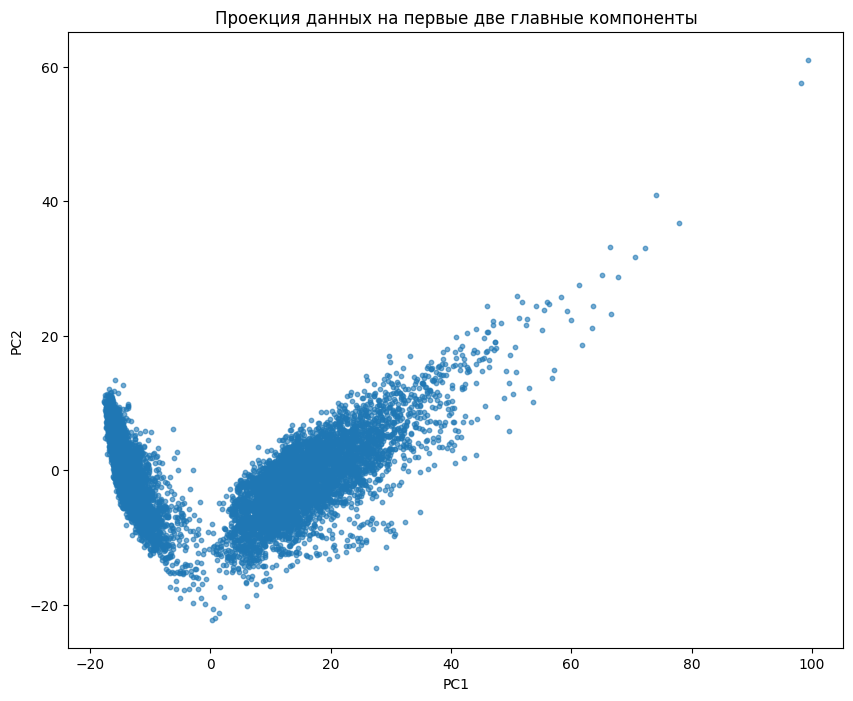

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=10,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Проекция данных на первые две главные компоненты")
plt.show()

### **Задание 19. (0.5 балла)**

Разберёмся с `KMeans`, [doc](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

- Сделайте кластеризацию данных методом `KMeans`, обучив модель на данных со сниженной за счет `PCA` размерностью. Нужно искать 6 кластеров (изначально у нас 6 классов). Засеките время обучения и время инференса.

**Параметры обучения:**

```n_clusters = 6``` (число уникальных меток целевого класса = 6)

```n_init = 100```

```random_state = RANDOM_STATE``` (для воспроизводимости результата, не забывайте указывать его и дальше!)

In [50]:
import time
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=6,
    n_init=100,
    random_state=RANDOM_STATE
)

t0 = time.perf_counter()
kmeans.fit(X_pca)
train_s = time.perf_counter() - t0

t1 = time.perf_counter()
clusters = kmeans.predict(X_pca)
infer_s = time.perf_counter() - t1

print("train_s:", train_s)
print("infer_s:", infer_s)
print("clusters:", len(set(clusters)))

train_s: 18.63648261599974
infer_s: 0.0036334500000521075
clusters: 6


### **Задание 20 (0.2 балла)**

- Визуализируйте данные в проекции на первые две главные компоненты.
- Раскрасьте точки в соответствии с полученными метками кластеров.

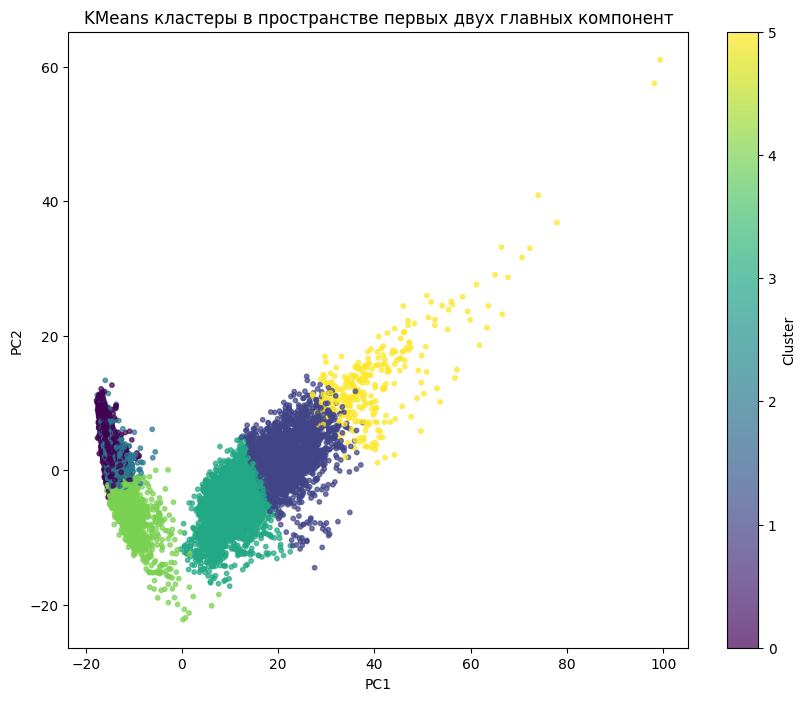

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=10,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans кластеры в пространстве первых двух главных компонент")
plt.colorbar(label="Cluster")
plt.show()

### **Задание 21 (0.3 балла)**

- Выберите какие-то метрики (минимум две) из известных вам. Объясните свой выбор
- Выведите на экран значения метрик качества, сделайте вывод о них и используйте их далее.

In [52]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

sil_score = silhouette_score(X_pca, clusters)
ch_score = calinski_harabasz_score(X_pca, clusters)

print("Silhouette Score:", sil_score)
print("Calinski-Harabasz Index:", ch_score)

Silhouette Score: 0.14149759467581463
Calinski-Harabasz Index: 3287.3625869943703


silhouette получился низкий (0.14 +-), значит кластеры разделены слабо и сильно пересекаются. kmeans при k=6 не очень хорошо уловил структуру данных. ch можно использовать дальше для сравнения моделей, но в целом видно, что разбиение не идеальное

### **Задание 22 (0.7 баллов)**

Теперь попробуем сделать кластеризацию с помощью `AgglomerativeClustering`, [doc](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

- Засеките время обучения и время инференса. После кластеризации также:
  - Вновь визуализируйте данные с раскраской по полученным меткам
  - Выведите метрики. Засеките время обучения и время инференса. Сравните с ```KMeans```.

Ответьте на следующие вопросы:
* Стало ли лучше?
* Почему?

In [53]:
import time
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=6)

t0 = time.perf_counter()
clusters_agg = agg.fit_predict(X_pca)
train_s_agg = time.perf_counter() - t0

infer_s_agg = train_s_agg

print("train_s:", train_s_agg)
print("infer_s:", infer_s_agg)

train_s: 12.849324459999934
infer_s: 12.849324459999934


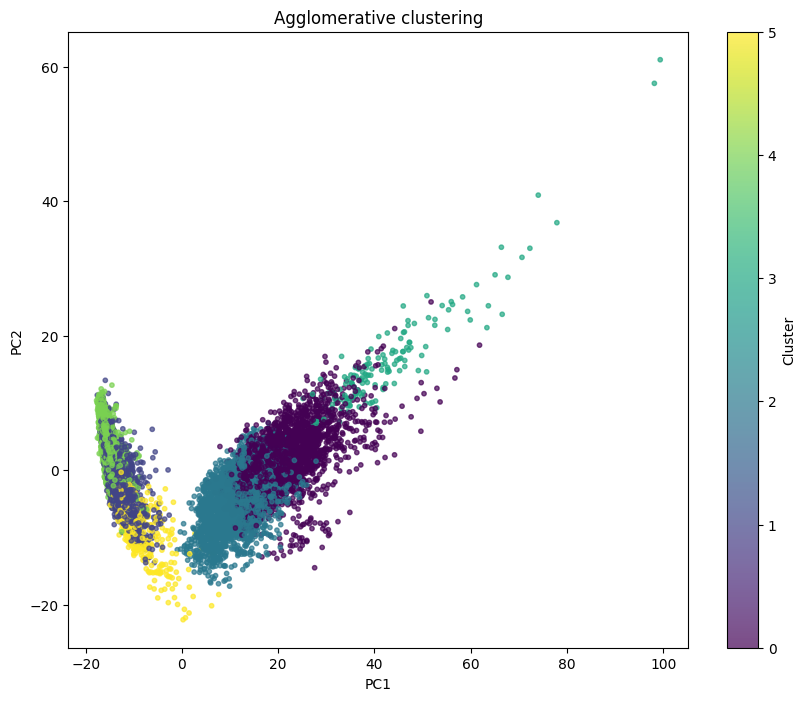

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_agg,
    cmap="viridis",
    s=10,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Agglomerative clustering")
plt.colorbar(label="Cluster")
plt.show()

In [55]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

sil_agg = silhouette_score(X_pca, clusters_agg)
ch_agg = calinski_harabasz_score(X_pca, clusters_agg)

print("Silhouette:", sil_agg)
print("Calinski-Harabasz:", ch_agg)

Silhouette: 0.1365817987962443
Calinski-Harabasz: 3021.2719742508134


**Ваш вывод здесь**

silhouette был ~0.14 у KMeans, стал ~0.137 - разделение слабое и даже немного просело.
ch тоже снизился (с ~3287 до ~3021).



### **Задание 23 (0.3 балла)**
Для самой успешной из полученных кластеризаций попробуйте дать интерпретацию кластеров. Опишите характеристики объектов, попавших в каждый кластер. Для этого можете ответить на следующие вопросы:

* Похожи ли объекты внутри каждого кластера на определенный тип активности человека?
* В каких кластерах смешано несколько типов активности? С чем, на ваш взгляд, это может быть связано?
* Качественная ли получилась кластеризация? На основании чего вы можете сделать такой вывод?

**Ваш вывод здесь**

1 Частично да - лучше всего отделяются статичные активности (сидение, лежание), динамические смешиваются.

2.
в кластерах с ходьбой, подъёмом и спуском - движения похожи по сигналам сенсоров, поэтому пересекаются.

3
Скорее средняя/слабая — silhouette низкий (+-0.14), значит кластеры плохо разделены.

## **Бонус-задание (1 балл)**
![RedPanda](http://imgur.com/6Aa52Lm.png)

Алгоритмы кластеризации могут применяться в самых разных задачах. Например, в анализе изображений есть задача разделения изображения на семантические компоненты, которую можно решать в том числе с помощью алгоритмов кластеризации. В бонусе предлагаем вам попрактиковаться именно в этом на чудесной утке и совах (```duck.jpg``` и ```owls.jpg```)

### **(0.1 балл)**

- Откройте изображения, после чего визуализируйте их с помощью ```plt.imshow()```

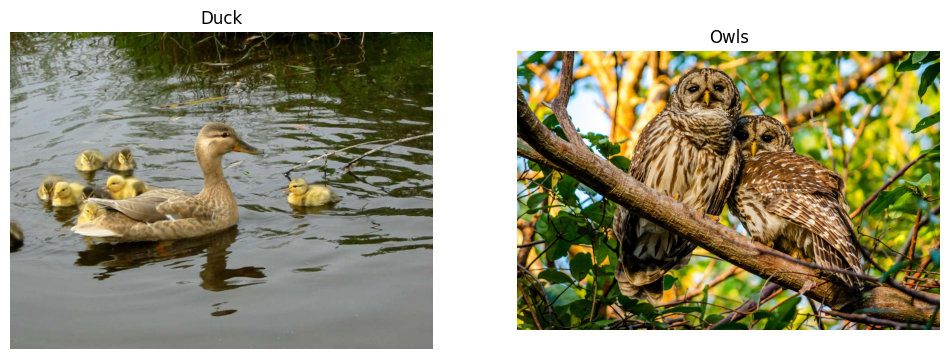

In [57]:
from matplotlib import pyplot as plt
from PIL import Image

duck = Image.open("duck.jpg")
owls = Image.open("Owls.jpg")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(duck)
plt.title("Duck")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(owls)
plt.title("Owls")
plt.axis("off")

plt.show()

### **(0.4 балла)**

Для каждого изображения, используя кластеризацию ```KMeans```, выделите компоненты, охарактеризовав каждый пиксель следующим образом: $$\psi_i = [\lambda x_i, \lambda y_i, r_i, g_i, b_i]$$
 где
- $x_i$ и $y_i$ — координаты пикселя,
- $r_i, g_i, b_i$ — его цвет,
- $\lambda$ — параметр, выражающий важность пространственной связности перед цветовой похожестью.

Примените полученную функцию, взяв следующие $\lambda$: 0.3 и 1.5 для ```duck.jpg``` и ```owls.jpg``` (или другие, но тогда с вас красивые результаты :) )

**Примечание:**
Число кластеров подберите разумным образом на свой вкус (в качестве нулевого приближения можно взять 3)

In [58]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def segment_image(img, n_clusters=3, lam=1.0):

    img_np = np.array(img)
    h, w, c = img_np.shape

    X_coords, Y_coords = np.meshgrid(np.arange(w), np.arange(h))

    features = np.concatenate([
        (lam * X_coords.reshape(-1, 1)),
        (lam * Y_coords.reshape(-1, 1)),
        img_np.reshape(-1, 3)
    ], axis=1)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(features)

    segmented = kmeans.cluster_centers_[labels][:, 2:5]
    segmented = segmented.reshape(h, w, 3).astype(np.uint8)

    return segmented

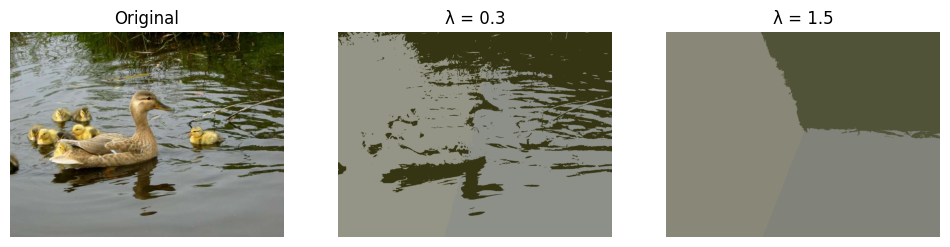

In [59]:
duck_seg_03 = segment_image(duck, n_clusters=3, lam=0.3)
duck_seg_15 = segment_image(duck, n_clusters=3, lam=1.5)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(duck)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(duck_seg_03)
plt.title("λ = 0.3")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(duck_seg_15)
plt.title("λ = 1.5")
plt.axis("off")

plt.show()

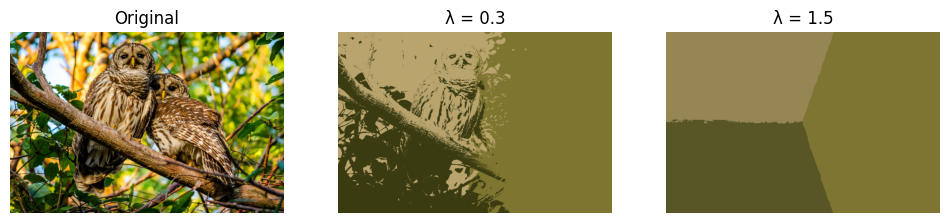

In [60]:
owls_seg_03 = segment_image(owls, n_clusters=3, lam=0.3)
owls_seg_15 = segment_image(owls, n_clusters=3, lam=1.5)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(owls)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(owls_seg_03)
plt.title("λ = 0.3")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(owls_seg_15)
plt.title("λ = 1.5")
plt.axis("off")

plt.show()

### **(0.4 балла)**

Попробуйте выделить сегменты при помощи [спектральной кластеризации](http://scikit-learn.org/stable/modules/clustering.html#spectral-clustering). Обратите внимание на [пример в sklearn](http://scikit-learn.org/0.16/auto_examples/cluster/plot_lena_segmentation.html).


**Примечание:**

Для ускорения работы алгоритма рекомендуется привести изображение к серому цвету. При необходимости можно сжать изображения в 2 раза.

**Подсказка:**```skimage``` с его ```color``` и ```transform``` в этом помогут :)

Или же воспользуйтесь аналогичными средствами ```PIL``` или ```cv2```

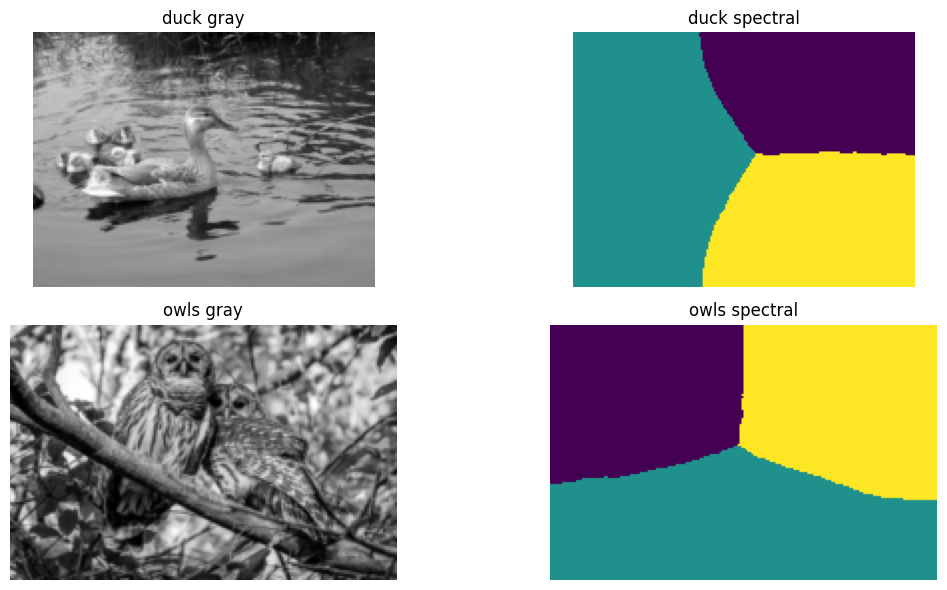

In [62]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import color, transform
from sklearn.feature_extraction import image
from sklearn.cluster import spectral_clustering

def spectral_segmentation(img, n_clusters=3, max_pixels=25000):

    img_np = np.array(img)
    gray = color.rgb2gray(img_np)

    h, w = gray.shape
    scale = (max_pixels / (h * w)) ** 0.5
    if scale < 1:
        nh, nw = max(10, int(h * scale)), max(10, int(w * scale))
        gray = transform.resize(gray, (nh, nw), anti_aliasing=True)

    graph = image.img_to_graph(gray)

    s = graph.data.std()
    if s == 0:
        s = 1.0
    graph.data = np.exp(-graph.data / s)

    labels = spectral_clustering(
        graph,
        n_clusters=n_clusters,
        eigen_solver="arpack",
        assign_labels="kmeans",
        random_state=42
    )

    return gray, labels.reshape(gray.shape)

gray_duck, seg_duck = spectral_segmentation(duck, n_clusters=3, max_pixels=25000)
gray_owls, seg_owls = spectral_segmentation(owls, n_clusters=3, max_pixels=25000)

plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1); plt.imshow(gray_duck, cmap="gray"); plt.axis("off"); plt.title("duck gray")
plt.subplot(2, 2, 2); plt.imshow(seg_duck, cmap="viridis"); plt.axis("off"); plt.title("duck spectral")

plt.subplot(2, 2, 3); plt.imshow(gray_owls, cmap="gray"); plt.axis("off"); plt.title("owls gray")
plt.subplot(2, 2, 4); plt.imshow(seg_owls, cmap="viridis"); plt.axis("off"); plt.title("owls spectral")

plt.tight_layout()
plt.show()

Ы%

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage import transform

def kmeans_labels(img, n_clusters=3, lam=1.0, random_state=42):
    a = np.array(img)
    h, w = a.shape[:2]

    yy, xx = np.mgrid[0:h, 0:w]
    feat = np.c_[lam * xx.ravel(), lam * yy.ravel(), a.reshape(-1, 3)]

    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    lab = km.fit_predict(feat)

    return lab.reshape(h, w)

def upsample_labels(labels, shape_hw):
    return transform.resize(
        labels,
        shape_hw,
        order=0,
        preserve_range=True,
        anti_aliasing=False
    ).astype(int)

def show_contours(img, labels2d, title=""):
    a = np.array(img)
    plt.figure(figsize=(10, 6))
    plt.imshow(a)
    plt.contour(labels2d, levels=np.unique(labels2d), linewidths=1.2)
    plt.title(title)
    plt.axis("off")
    plt.show()

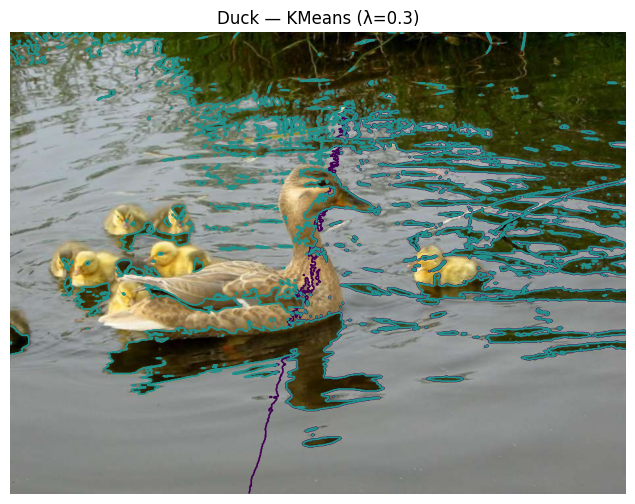

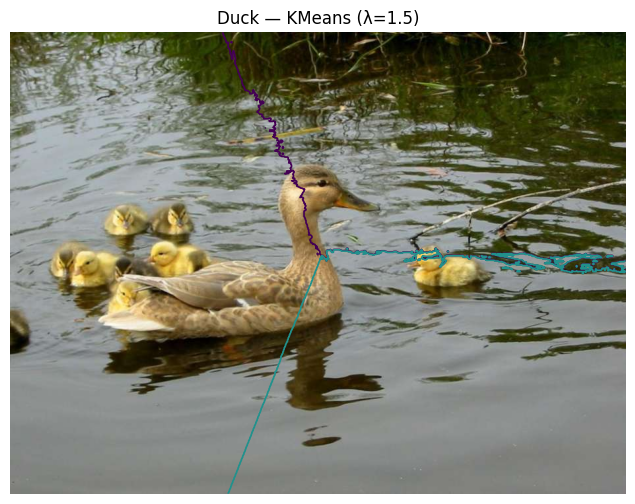

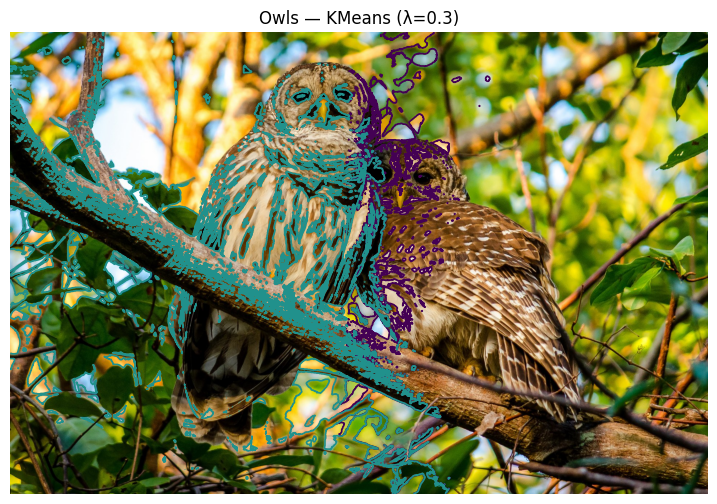

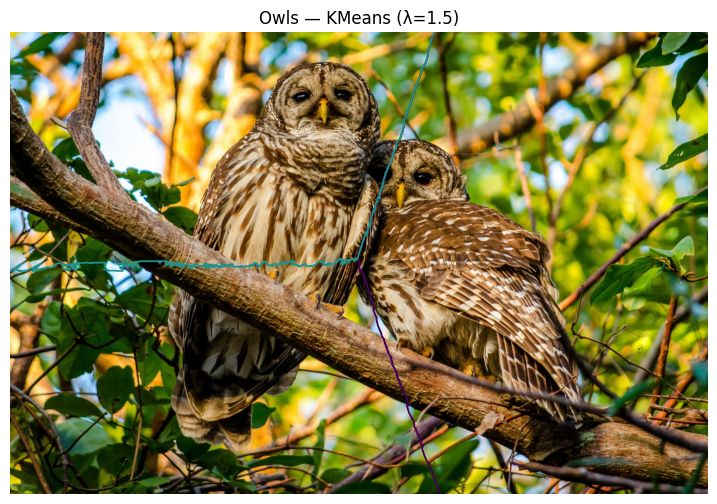

In [68]:
duck_km_03 = kmeans_labels(duck, n_clusters=3, lam=0.3, random_state=42)
duck_km_15 = kmeans_labels(duck, n_clusters=3, lam=1.5, random_state=42)

owls_km_03 = kmeans_labels(owls, n_clusters=3, lam=0.3, random_state=42)
owls_km_15 = kmeans_labels(owls, n_clusters=3, lam=1.5, random_state=42)

show_contours(duck, duck_km_03, "Duck — KMeans (λ=0.3)")
show_contours(duck, duck_km_15, "Duck — KMeans (λ=1.5)")

show_contours(owls, owls_km_03, "Owls — KMeans (λ=0.3)")
show_contours(owls, owls_km_15, "Owls — KMeans (λ=1.5)")

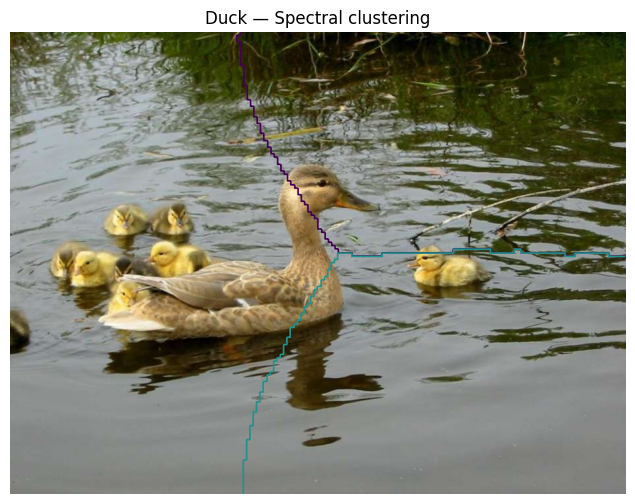

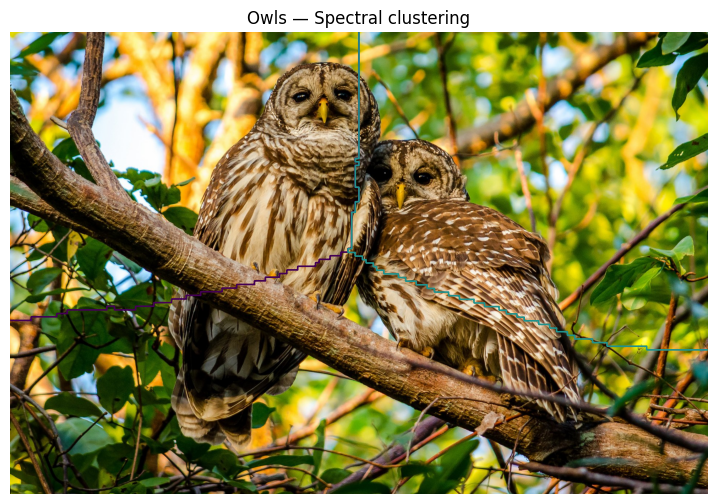

In [69]:
duck_spec = upsample_labels(seg_duck, np.array(duck).shape[:2])
owls_spec = upsample_labels(seg_owls, np.array(owls).shape[:2])

show_contours(duck, duck_spec, "Duck — Spectral clustering")
show_contours(owls, owls_spec, "Owls — Spectral clustering")

**Спасибо! Вы — человек — большой трудяга!**

Успокоительный кот :)

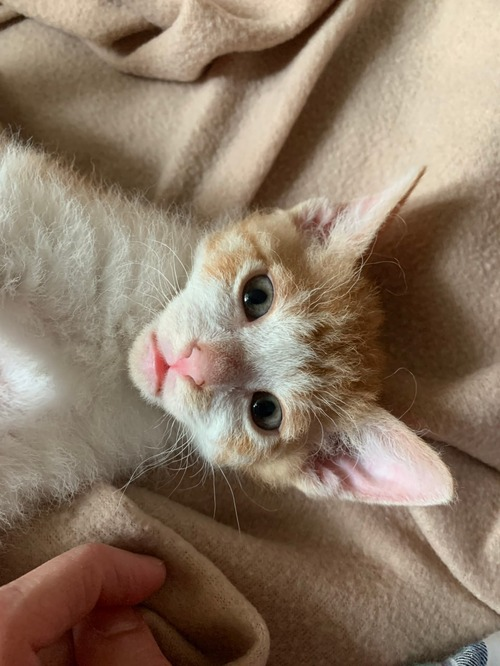